In [ ]:
%pip install -e "/content/drive/MyDrive/BUSI-XAI"

Obtaining file:///content/drive/MyDrive/BUSI-XAI
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for busi-xai (pyproject.toml) ... done
  Created wheel for busi-xai: filename=busi_xai-0.1.0-0.editable-py3-none-any.whl size=1176 sha256=f4c59ee3b004568bac7fa9056addea36dfa164d2c6981eb22c6999a704e8c6c6
  Stored in directory: /tmp/pip-ephem-wheel-cache-_fxc2wb1/wheels/bc/96/6a/14ad5b6a03036f6f181aa62fbcb8d63ac3b6cb1da04fcdcb1e
Successfully built busi-xai
  Attempting uninstall: busi-xai
    Found existing installation: busi-xai 0.1.0
    Uninstalling busi-xai-0.1.0:
      Successfully uninstalled busi-xai-0.1.0


# Generate **preprocessed** data

In [ ]:
from busi_xai.preprocessing import preprocess_dataset , discover_dataset


In [ ]:

results = preprocess_dataset()

len(results)

2026-09-30 18:52:13,096 | INFO | Starting BUSI preprocessing.
2026-09-30 18:52:13,101 | INFO | Raw dataset: /content/drive/MyDrive/BUSI-XAI/data/raw
2026-09-30 18:52:13,922 | INFO | Discovered 647 images.
2026-09-30 18:52:14,469 | INFO | Processed 1/647: benign (1).png
2026-09-30 18:52:15,244 | INFO | Processed 2/647: benign (10).png
2026-09-30 18:52:15,609 | INFO | Processed 3/647: benign (100).png
2026-09-30 18:52:22,730 | INFO | Processed 4/647: benign (101).png
2026-09-30 18:52:23,147 | INFO | Processed 5/647: benign (102).png
2026-09-30 18:52:23,539 | INFO | Processed 6/647: benign (103).png
2026-09-30 18:52:24,001 | INFO | Processed 7/647: benign (104).png
2026-09-30 18:52:24,533 | INFO | Processed 8/647: benign (105).png
2026-09-30 18:52:25,043 | INFO | Processed 9/647: benign (106).png
2026-09-30 18:52:25,239 | INFO | Processed 10/647: benign (107).png
2026-09-30 18:52:25,493 | INFO | Processed 11/647: benign (108).png
2026-09-30 18:52:25,624 | INFO | Processed 12/647: benign (

647

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

df.head()

,image_id,class_name,source_image,processed_image,processed_mask,num_masks,mask_paths,image_width,image_height,mask_width,mask_height,mask_empty,lesion_pixels,lesion_area_ratio,image_sha256,include_in_experiment,exclusion_reason
0,benign (1),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,/content/drive/MyDrive/BUSI-XAI/data/processed...,/content/drive/MyDrive/BUSI-XAI/data/processed...,1,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,562,471,562,471,False,984,0.003717,6941fb64feb59a1654e5d4406d38154f1c894aaa4b8060...,True,
1,benign (10),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,/content/drive/MyDrive/BUSI-XAI/data/processed...,/content/drive/MyDrive/BUSI-XAI/data/processed...,1,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,683,585,683,585,False,32918,0.082387,05168bd19ca6820136249f830b97aae5e0baead5dad117...,True,
2,benign (100),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,/content/drive/MyDrive/BUSI-XAI/data/processed...,/content/drive/MyDrive/BUSI-XAI/data/processed...,2,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,323,473,323,473,False,10011,0.065526,22fe3fc5bc7366214a53f9e7468c1a297ed49055a889b1...,True,
3,benign (101),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,/content/drive/MyDrive/BUSI-XAI/data/processed...,/content/drive/MyDrive/BUSI-XAI/data/processed...,1,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,563,473,563,473,False,4167,0.015648,737ea97bbe347b92271b4d77b9a95c6534bdb057e569c2...,True,
4,benign (102),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,/content/drive/MyDrive/BUSI-XAI/data/processed...,/content/drive/MyDrive/BUSI-XAI/data/processed...,1,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,634,610,634,610,False,18857,0.048759,f90bf5c1123179a7c2544e07727f9fe6829af143dc1479...,True,


# Inspect generated **preprocessed** data

In [ ]:
print("Total processed images:", len(df))

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nNumber of masks per image:")
print(df["num_masks"].value_counts().sort_index())

print("\nEmpty processed masks:")
print(df["mask_empty"].sum())

print("\nDimension mismatches:")
print(
    (
        (df["image_width"] != df["mask_width"])
        | (df["image_height"] != df["mask_height"])
    ).sum()
)

Total processed images: 647

Class distribution:
class_name
benign       437
malignant    210
Name: count, dtype: int64

Number of masks per image:
num_masks
1    630
2     16
3      1
Name: count, dtype: int64

Empty processed masks:
0

Dimension mismatches:
0


# Images with multiple masks

In [ ]:
multi_mask = df[df["num_masks"] > 1]

print("Images with multiple masks:", len(multi_mask))
display(
    multi_mask[
        [
            "image_id",
            "class_name",
            "num_masks",
            "lesion_pixels",
            "lesion_area_ratio",
        ]
    ]
)

Images with multiple masks: 17


,image_id,class_name,num_masks,lesion_pixels,lesion_area_ratio
2,benign (100),benign,2,10011,0.065526
71,benign (163),benign,2,4564,0.010172
82,benign (173),benign,2,42335,0.101767
91,benign (181),benign,2,26899,0.080653
106,benign (195),benign,3,156339,0.350993
167,benign (25),benign,2,5824,0.012974
240,benign (315),benign,2,8256,0.031880
274,benign (346),benign,2,38191,0.167850
333,benign (4),benign,2,2608,0.010106
361,benign (424),benign,2,5376,0.021071


# Lesion area distribution

In [ ]:
df["lesion_area_ratio"].describe()

,lesion_area_ratio
count,647.000000
mean,0.094354
std,0.098776
min,0.002812
25%,0.022401
50%,0.057643
75%,0.130898
max,0.562924


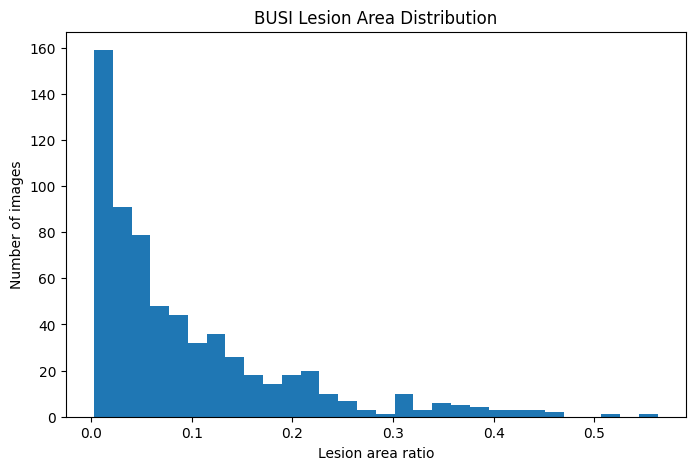

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["lesion_area_ratio"], bins=30)
plt.xlabel("Lesion area ratio")
plt.ylabel("Number of images")
plt.title("BUSI Lesion Area Distribution")
plt.show()

# Exact duplicates

In [ ]:
duplicate_groups = (
    df.groupby("image_sha256")
    .filter(lambda group: len(group) > 1)
    .sort_values("image_sha256")
)

display(
    duplicate_groups[
        [
            "image_id",
            "class_name",
            "source_image",
            "image_sha256",
        ]
    ]
)

,image_id,class_name,source_image,image_sha256
371,benign (433),benign,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...
488,malignant (145),malignant,/content/drive/MyDrive/BUSI-XAI/data/raw/malig...,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...


# Exclusion decision

In [ ]:
print("Total records:", len(df))
print("Included:", df["include_in_experiment"].sum())
print("Excluded:", (~df["include_in_experiment"]).sum())

display(
    df.loc[
        ~df["include_in_experiment"],
        [
            "image_id",
            "class_name",
            "image_sha256",
            "include_in_experiment",
            "exclusion_reason"
        ]
    ]
)

Total records: 647
Included: 645
Excluded: 2


,image_id,class_name,image_sha256,include_in_experiment,exclusion_reason
371,benign (433),benign,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...,False,duplicate_image_conflicting_labels
488,malignant (145),malignant,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...,False,duplicate_image_conflicting_labels


# Data set distribution after exclusion

In [ ]:
experimental_df = df[df["include_in_experiment"]].copy()

print("Experimental dataset size:", len(experimental_df))
print("\nClass distribution:")
print(experimental_df["class_name"].value_counts())

Experimental dataset size: 645

Class distribution:
class_name
benign       436
malignant    209
Name: count, dtype: int64


# Save preprocessng report

In [ ]:
from busi_xai.config import METRICS_DIR

METRICS_DIR.mkdir(parents=True, exist_ok=True)

manifest_path = METRICS_DIR / "preprocessing_manifest.csv"

df.to_csv(manifest_path, index=False)

print(f"Saved: {manifest_path}")

Saved: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/preprocessing_manifest.csv


# Create data **splits**

In [ ]:
from busi_xai.config import METRICS_DIR
from busi_xai.splitting import create_splits

manifest_path = METRICS_DIR / "preprocessing_manifest.csv"

train_df, validation_df, test_df = create_splits(manifest_path)

# Investigate data **splits**

In [ ]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(validation_df) + len(test_df))

Train: 451
Validation: 97
Test: 97
Total: 645


# Verify class distribution in data splits

In [ ]:
print("TRAIN")
print(train_df["class_name"].value_counts())

print("\nVALIDATION")
print(validation_df["class_name"].value_counts())

print("\nTEST")
print(test_df["class_name"].value_counts())

TRAIN
class_name
benign       305
malignant    146
Name: count, dtype: int64

VALIDATION
class_name
benign       65
malignant    32
Name: count, dtype: int64

TEST
class_name
benign       66
malignant    31
Name: count, dtype: int64


In [ ]:
for name, split_df in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(f"\n{name}")
    print(split_df["class_name"].value_counts(normalize=True))


Train
class_name
benign       0.676275
malignant    0.323725
Name: proportion, dtype: float64

Validation
class_name
benign       0.670103
malignant    0.329897
Name: proportion, dtype: float64

Test
class_name
benign       0.680412
malignant    0.319588
Name: proportion, dtype: float64


# Check data splits overlap

In [ ]:
train_ids = set(train_df["image_id"])
validation_ids = set(validation_df["image_id"])
test_ids = set(test_df["image_id"])

print("Train ∩ Validation:", len(train_ids & validation_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(validation_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
all_ids = train_ids | validation_ids | test_ids

print("Unique split images:", len(all_ids))

Unique split images: 645


# Check **excluded** data in data splits

In [ ]:
import pandas as pd

excluded_ids = set(
    pd.read_csv(manifest_path)
    .query("include_in_experiment == False")["image_id"]
)

print("Excluded records:", len(excluded_ids))
print("Excluded records in splits:", len(
    excluded_ids & (train_ids | validation_ids | test_ids)
))

Excluded records: 2
Excluded records in splits: 0


In [ ]:
import json
from busi_xai.config import SPLITS_DIR
from busi_xai.splitting import SPLIT_CONFIG

config_path = SPLITS_DIR / "split_config.json"

with open(config_path, "w") as f:
    json.dump(SPLIT_CONFIG, f, indent=2)

print(f"Saved: {config_path}")

Saved: /content/drive/MyDrive/BUSI-XAI/data/splits/split_config.json


In [ ]:
import pandas as pd

from busi_xai.config import METRICS_DIR

manifest_path = METRICS_DIR / "preprocessing_manifest.csv"

manifest = pd.read_csv(manifest_path)

included = manifest[manifest["include_in_experiment"] == True]

print(f"Total manifest records: {len(manifest)}")
print(f"Included experimental images: {len(included)}")
print(f"Excluded records: {len(manifest) - len(included)}")

Total manifest records: 647
Included experimental images: 645
Excluded records: 2
